# Week 7 Activity: Pandas Practice and Binomial Classification

Complete this activity as part of your participation grade. Pending length of the lecture, you will have time in class to work. Everything you need to complete this activity can be found in this week's (or a previous week's) lecture code.

In this activity, you will build a binomial classifier with logistic regression. You will use the GTZAN genre dataset 'features_30_sec.csv' to classify rock vs classical music.

In [37]:
import numpy as np
from scipy.io.wavfile import read
from scipy import signal
from librosa import feature, load, frames_to_time
import matplotlib.pyplot as plt
from sklearn import preprocessing
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

### Filter dataset

First, read the csv into a dataframe. Then, create a new dataframe that only includes rock and classical samples.

In [6]:
df = pd.read_csv('/Users/jocelynkavanagh/Documents/Code/MUSI2626/AudioTechII-Live/Datasets/features_30_sec.csv')
genres = ['rock', 'classical']
df = df[df['label'].isin(genres)]

### Explore the data

Use graphing and correlation techniques to determine 5 features you will use for your classification.

You should at a minimum create a bar graph and a box plot and compute the correlation between a few features (especially those you plan to select).

Outside of variability in the data, think about why certain features may help us differentiate the two categories based on musical reasoning. 

In [11]:
columns_to_keep = ['label', 'rms_mean', 'spectral_centroid_mean', 'spectral_bandwidth_mean', 'rolloff_mean', 'zero_crossing_rate_mean']
df = df[columns_to_keep]

<AxesSubplot: title={'center': 'RMS Mean by label'}, xlabel='label'>

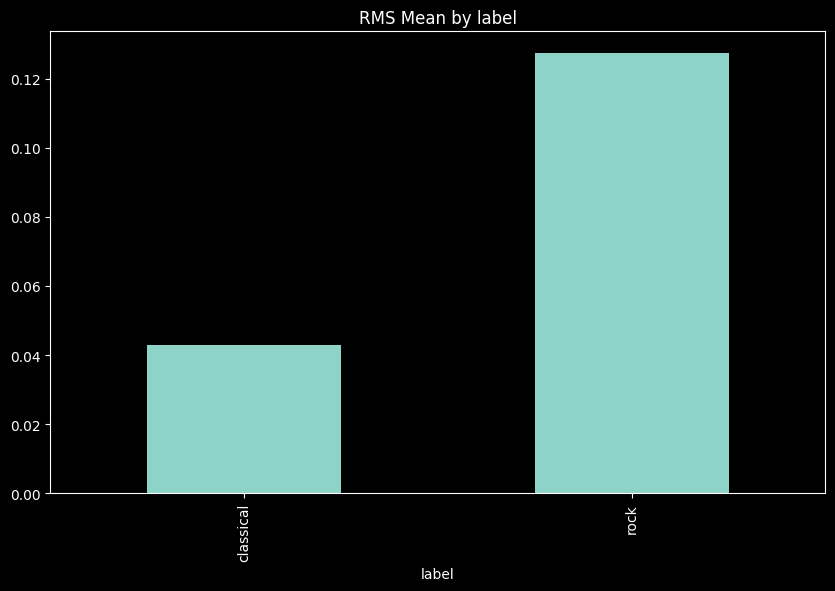

In [8]:
genre_rms = df.groupby('label')['rms_mean'].mean()
genre_rms.plot.bar(figsize=(10, 6), title='RMS Mean by label')

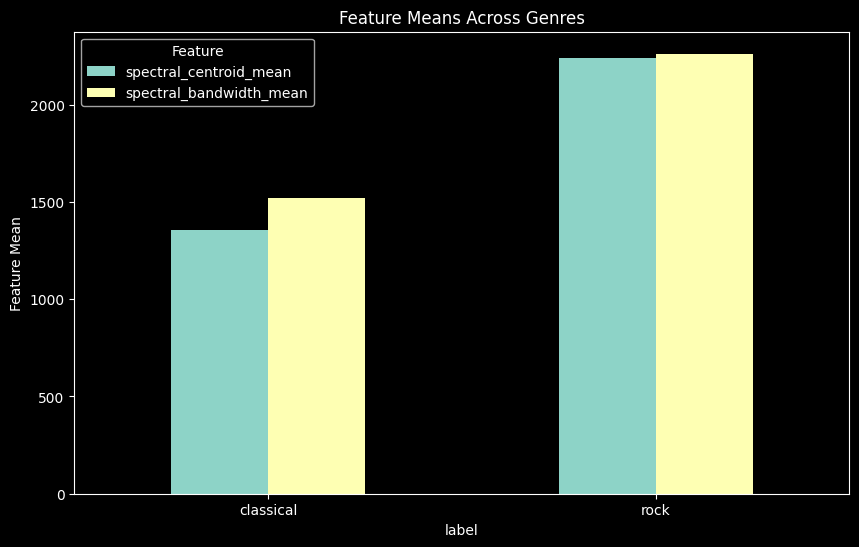

In [9]:
grouped = df.groupby("label").mean(numeric_only=True)
features = [
    "spectral_centroid_mean",
    "spectral_bandwidth_mean"
]

grouped_features = grouped[features]
grouped_features.plot.bar(figsize=(10, 6), title='Feature Mean by label')
plt.ylabel("Feature Mean")
plt.title("Feature Means Across Genres")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()

<Figure size 640x480 with 0 Axes>

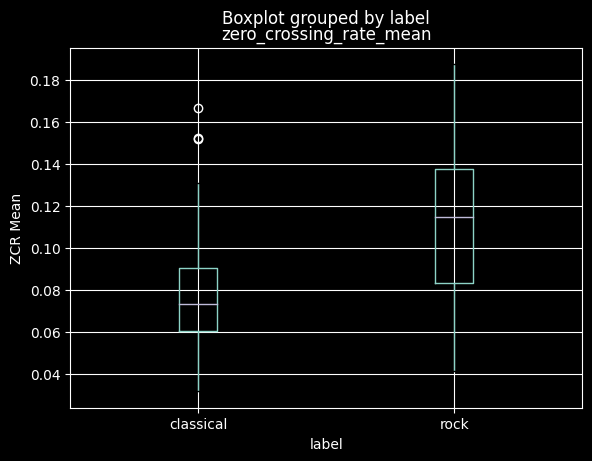

In [10]:
plt.figure()
df.boxplot(column="zero_crossing_rate_mean", by="label")
plt.ylabel("ZCR Mean")
plt.show()

In [14]:
genre = pd.get_dummies(df['label'],drop_first=True)
df.drop(['label'],axis=1,inplace=True)
df = pd.concat([genre,df],axis=1) #good practice to put the target variable in the first (or last) column
df.head()

,rock,rms_mean,spectral_centroid_mean,spectral_bandwidth_mean,rolloff_mean,zero_crossing_rate_mean
100,0,0.036245,1505.166424,1559.005740,2716.306158,0.098223
101,0,0.030625,1360.643672,1441.243134,2387.729130,0.087766
102,0,0.043860,1490.275364,1600.115744,2785.294011,0.090046
103,0,0.029442,1526.629882,1499.439342,2916.000387,0.108946
104,0,0.042316,1705.563259,1646.064010,3174.931743,0.112857


In [ ]:
df.corr()

,rock,rms_mean,spectral_centroid_mean,spectral_bandwidth_mean,rolloff_mean,zero_crossing_rate_mean
rock,1.000000,0.723609,0.727290,0.774017,0.775606,0.458102
rms_mean,0.723609,1.000000,0.574018,0.583565,0.589461,0.411140
spectral_centroid_mean,0.727290,0.574018,1.000000,0.914868,0.984305,0.886006
spectral_bandwidth_mean,0.774017,0.583565,0.914868,1.000000,0.951711,0.650474
rolloff_mean,0.775606,0.589461,0.984305,0.951711,1.000000,0.805752
zero_crossing_rate_mean,0.458102,0.411140,0.886006,0.650474,0.805752,1.000000


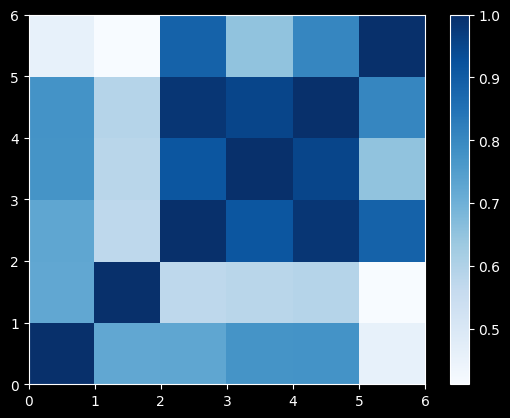

In [17]:
plt.pcolor(df.corr(), cmap='Blues') 
plt.colorbar()

Spectral centroid, rolloff, and bandwidth are highly correlated so I'm going to drop all but centroid and add in MFCC 1 and MFCC 2

In [19]:
columns_to_keep = ['label', 'rms_mean', 'spectral_centroid_mean', 'mfcc1_mean', 'mfcc2_mean', 'zero_crossing_rate_mean']
df = pd.read_csv('/Users/jocelynkavanagh/Documents/Code/MUSI2626/AudioTechII-Live/Datasets/features_30_sec.csv')
genres = ['rock', 'classical']
df = df[df['label'].isin(genres)]
df = df[columns_to_keep]

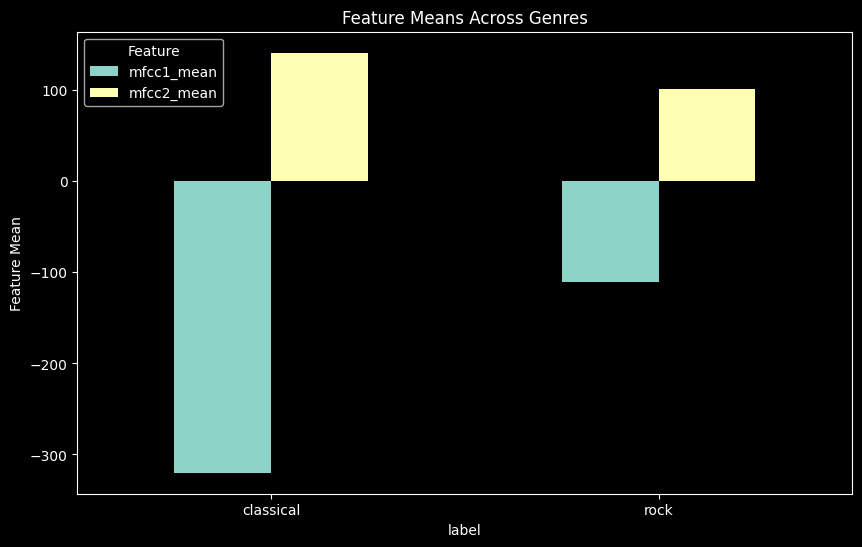

In [20]:
grouped = df.groupby("label").mean(numeric_only=True)
features = [
    "mfcc1_mean",
    "mfcc2_mean"
]

grouped_features = grouped[features]
grouped_features.plot.bar(figsize=(10, 6), title='Feature Mean by label')
plt.ylabel("Feature Mean")
plt.title("Feature Means Across Genres")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()

In [21]:
genre = pd.get_dummies(df['label'],drop_first=True)
df.drop(['label'],axis=1,inplace=True)
df = pd.concat([genre,df],axis=1) #good practice to put the target variable in the first (or last) column
df.head()

,rock,rms_mean,spectral_centroid_mean,mfcc1_mean,mfcc2_mean,zero_crossing_rate_mean
100,0,0.036245,1505.166424,-268.195526,135.691971,0.098223
101,0,0.030625,1360.643672,-324.061157,133.594574,0.087766
102,0,0.043860,1490.275364,-235.253723,141.109985,0.090046
103,0,0.029442,1526.629882,-326.861084,127.402405,0.108946
104,0,0.042316,1705.563259,-259.915131,118.950165,0.112857


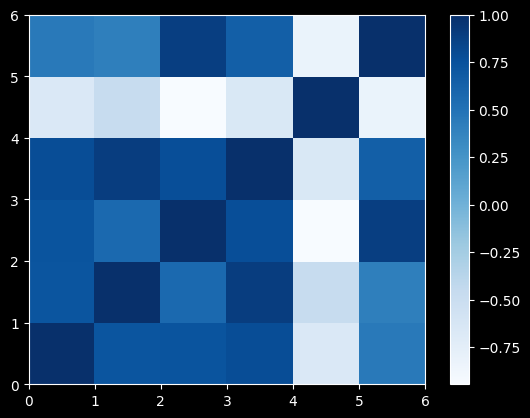

In [22]:
plt.pcolor(df.corr(), cmap='Blues') 
plt.colorbar()

That looks a bit better!

### Define your feature matrix

Set your x and y based on your selected features and the label outcome.
Note: you will need to convert your 'label' column to 0 and 1. You can do so manually or with .get_dummies

In [28]:
#"categories" is my set of dependent variables; the thing I am trying to classify by
categories = df.iloc[:,1:]
predictors = df.iloc[:,0]

predictors.head()

100    0
101    0
102    0
103    0
104    0
Name: rock, dtype: uint8

### Scale your feature matrix

Use StandardScaler to scale your feature matrix.

What would happen if you didn't scale?

I'm actually going to do this after the train/test split!

If you skip scaling: Features with large ranges bias the model.

### Train/Test Split

Use sklearn to split your data into testing and training sets. Remember you will need to define your categories, predictors, and test size. For this activity, use 30% test size.

In [ ]:
pred_train, pred_test, cat_train, cat_test = train_test_split(categories, predictors, test_size = .3, random_state=25)

In [47]:
# normalize

pred_train=(pred_train-pred_train.mean())/pred_train.std()
pred_test=(pred_test-pred_test.mean())/pred_test.std()

### Train the Model

Train the model using logistic regression.

Take a look at your model's coefficients. What do they tell you about each feature's contribution to the model?

In [48]:
model = LogisticRegression(solver='lbfgs') #for simple binary logistic regression we can use all default parameters
model.fit(pred_train, cat_train)
predictions = model.predict(pred_test)

In [49]:
coeffs = pd.Series(model.coef_[0])
coeffs = dict(zip(df.columns[1:], model.coef_[0]))
coeffs

{'rms_mean': 0.7084045873003728,
 'spectral_centroid_mean': 2.0170049906917713,
 'mfcc1_mean': 1.5159140687329504,
 'mfcc2_mean': -1.3298608142605552,
 'zero_crossing_rate_mean': -1.7574831677926597}

The coeffs show how strongly a feature influences the prediction. Positive coeffs push toward rock and negative coeffs push toward classical. Spectral centroid for example has a large effect on the model to infer rock.

### Evaluate

Calculate the confusion matrix (and view as a data frame).

What does the matrix tell you? What error type occurs most often?

In [50]:
cm = confusion_matrix(cat_test, predictions) #parameters are y_truth (i.e.,Ground truth (correct) target values), y_pred (i.e., predicted values from model).
pd.DataFrame(cm, columns=['Classical','Rock'], index=['Predicts_classical','Predicts_rock'])

,Classical,Rock
Predicts_classical,28,1
Predicts_rock,0,31


Calculate the accuracy, precision, recall, and F1 scores.

What is your models accuracy?

In [51]:
from sklearn.metrics import classification_report, precision_recall_fscore_support
print(classification_report(cat_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.97      1.00      0.98        31

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



### Extension

Try again using a different feature set or try using the same feature set but with new genres. How does changing features impact your model? How do the same features apply to different genres?

## Extra Pandas practice

You will work with pandas dataframes a lot for Python MIR applications. Here are some more exercises to practice using the Pandas library.

### Practice with pandas Series and Dataframes

#### Making Data & Converting arrays to Series
Let's practice taking some `numpy` arrays and converting them to Series and Dataframe objects.

1. a) Make a numpy array from 2 to 20 with only even numbers.  
b) Make another numpy array from 1 to 19 with only odd numbers.  
c) Wrap each array in a pandas.Series() function to make it a Series object.  

In [ ]:
# Pause and try it

2. Use `np.vstack()` to combine (a) and (b) above into a multidimensional array 

In [ ]:
# stack 2 numpy arrays to 2d array

3. transpose the array (i.e., rotate so that columns become rows)

In [ ]:
# transpose array with the array object's transpose() method 

4. pass your 2d array to a pandas Dataframe function to create a dataframe. Give it a name and save it as a variable.

In [ ]:
# create dataframe

5. Name your columns. Call them "odd" and "even"

In [ ]:
# name the columns with the .columns() method (remember to make it a list!)

#### Read in existing data from a .csv file

Let's practice creating a `pandas` object directly through loading a .csv object. Let's open the file: "weather.csv" from the "Datasets" folder

In [ ]:
# load data with the `pandas.read_csv()` function.
import pandas as pd

df = pd.read_csv('../Datasets/weather.csv')

6. look at the uniqe list of city names from the city column with the `unique()` method

In [ ]:
# how many different cities in the dataframe

7. Count up how many data observations for each city (i.e., how many rows does each unique city name repeat?) Use the `value_counts()` method

In [ ]:
# what are the count values for each city?
df.head()

8. Calculate the mean and standard deviation of the `avg_temp` column using the `.mean()` and `.std()` methods

In [ ]:
# 

#### Plotting

Basic plotting can be done right from your pandas dataframe object if you just want a simple graph:

| Plot Type       | Usage                            | Description / Example Use        |
|------------------|----------------------------------|-----------------------------------|
| **Line**         | `.plot()` or `.plot.line()`     | Default for time series / trends |
| **Bar**          | `.plot.bar()`                   | Vertical bar plot                |
| **Histogram**    | `.plot.hist()`                  | Distribution of values           |
| **Box**          | `.plot.box()`                   | Box-and-whisker plot             |
| **Scatter**      | `.plot.scatter(x='x', y='y')`   | Requires `x` and `y`             |


9. Make a line plot (across all data) with the high temp in red and the low temp in blue

In [ ]:
# First, select only the two columns you care about:

subset = df[['high_temp', 'low_temp']]

# plot them with colors
subset.plot(color=['red', 'blue'])

# if you want to set a title, you have to save the plot as a variable ("ax" is common) and then apply a title, like this:

ax = subset.plot(color=['red', 'blue'])
ax.set_title("High and Low Annual temperatures")


In [ ]:
# Let's instead try a "range" or "lolipop" plot where we plot the *distance* between the low and high temp for each row
# For more sophisticated plots like this we need matplotlib, we can simply pass the series directly to matplot library:
import matplotlib.pyplot as plt

# Plot the points (as before) with red and blue:
x = df.index # these are the row numbers!

# Set the figure size to widen it:
plt.figure(figsize = (14, 6))

plt.scatter(x, df['high_temp'], color='red', label='High Temp')
plt.scatter(x, df['low_temp'], color='blue', label='Low Temp')

# Next draw vertical lines between the points with `plt.vlines(x, y1, y2)`
plt.vlines(x, df['low_temp'], df['high_temp'], color='purple', alpha=0.6)


10. Make a new column of made up data to add to the weather dataframe. Let's call it "predicted_weather"
Using the values from the "events" column, let us randomly select values and put them in our new column. (You will not be making up data but you do need to know how to take a Series or array and "paste" it into an existing dataframe.

In [ ]:
df.events.unique() # note some are lists...

In [ ]:
# save a list variable returning some single events from the "events" column
unique_weather = ["Rain","Fog", "Hail", "Snow", "Thunderstorm"]

In [ ]:
# use numpy's `random.choice()` function to randomly select from your variable. 
import numpy as np
newcoldata = np.random.choice(unique_weather, size = len(df))

# add the newcoldata as a new column of data into your existing dataframe:
df['predicted_weather'] = newcoldata

11. Make a cross-tabulation (confusion matrix) for categorical variables using the `pd.crosstab()` function. Let us look at where our "events" matches our "predicted weather"

In [ ]:
# replace my variables with the appropriate column names to compute the cross tabulation
pd.crosstab(column1, column2)